In [95]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from brainspace.null_models import SpinPermutations
#from enigmatoolbox.permutation_testing import spin_test, shuf_test
from scipy.stats import ttest_ind
from natsort import natsorted
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import glob
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
from scipy.stats import linregress
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import nibabel as nib
import sys
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from nibabel import cifti2
from scipy.spatial import procrustes
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind, ttest_rel
np.random.seed(42)

In [96]:
blind_MMP_rh = np.load('../Derivatives/blindsource_blindtarget_individual_fingerprint_fc_rh_Schaefer2YeoThalamus.npy')
blind_MMP_lh = np.load('../Derivatives/blindsource_blindtarget_individual_fingerprint_fc_lh_Schaefer2YeoThalamus.npy')
control_MMP_rh = np.load('../Derivatives/controlsource_controltarget_individual_fingerprint_fc_rh_Schaefer2YeoThalamus.npy')
control_MMP_lh = np.load('../Derivatives/controlsource_controltarget_individual_fingerprint_fc_lh_Schaefer2YeoThalamus.npy')

In [97]:
region_label = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 8,
       8, 8, 2, 8, 8, 8, 8, 8, 8, 8, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 8, 8, 8, 2, 8, 8, 2, 8, 8, 8, 8, 8, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 2,
       2, 8, 2, 8]

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Auditory']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

In [98]:
labels, ctab, names = nib.freesurfer.read_annot('/mnt/DataDrive3/NishioM/Blind/template/rh.HCPMMP1.annot')
roi_names = [name.decode('utf-8') for name in names]
MMPname = roi_names[1:]

# Blind

In [99]:
nucleis = np.load('/mnt/DataDrive3/NishioM/Blind/derivatives/yeo_thalamus_left_labels_Italy.npy')
nucleilabel = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']

In [100]:
wanglabel = pd.read_csv('/mnt/DataDrive3/NishioM/Blind/template/Wang/ROIfiles_Labeling.txt', sep='\t')
wanglabel = [x.split('- ')[1] for x in wanglabel.index.values]
len(wanglabel)

25

In [101]:
cb = pd.read_csv('/mnt/DataDrive3/NishioM/Blind/derivatives/fingerprint_FC_dataset/Italy_blind_subjects', header=None)[0].values
sc = pd.read_csv('/mnt/DataDrive3/NishioM/Blind/derivatives/fingerprint_FC_dataset/Italy_control_subjects', header=None)[0].values

In [102]:
blind_V1 = []
blind_A1 = []
for i in np.arange(blind_MMP_lh.shape[0]):
    corr_matrix = blind_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    V1_cols = [idx for idx, label in enumerate(region_label[200:]) if label==1]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    blind_V1.append(avg_visual)

In [103]:
control_V1 = []
for i in np.arange(control_MMP_lh.shape[0]):
    corr_matrix = control_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)#.T / pd.DataFrame(corr_matrix).mean(axis=1)
    #corr_df = corr_df.T
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    visual_df = corr_df.iloc[:, V1_cols]
    avg_visual = visual_df.mean(axis=1).values #/ corr_df.mean(axis=1).values
    control_V1.append(avg_visual)

In [104]:
df_V1 = pd.concat([pd.DataFrame(blind_V1), pd.DataFrame(control_V1)]).reset_index(drop=True)
df_V1.columns = nucleis
df_V1['group'] = list(np.repeat('blind', len(blind_V1))) +  list(np.repeat('control', len(control_V1)))

In [105]:
features = df_V1.iloc[:, :-1]
group = df_V1['group']
df_V1_network = features.T.groupby(features.columns).mean().T
#df_V1_network = df_V1_network.div(features.mean(axis=1), axis=0)
df_V1_network.columns = nucleilabel 
#df_V1_network['subject'] = list(cb) + list(sc)
df_V1_network['group'] = group
#df_V1_network = df_V1_network[df_V1_network.LGN>-120]
#df_V1_network = df_V1_network[df_V1_network.LGN<10]

In [106]:
df_V1_network.columns = ['V1_'+x for x in nucleilabel] + ['group']
df_V1_network['subject'] = list(cb) + list(sc)

In [107]:
blind_A1 = []
for i in np.arange(blind_MMP_lh.shape[0]):
    corr_matrix = blind_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[:200]
    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0).mean()
        .groupby(level=0, axis=1).mean()
    )
    blind_A1.append(corr_df_grouped.values)
blind_A1 = np.mean(blind_A1, axis=0)
blind_A1 = pd.DataFrame(
    blind_A1,
    index=['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default'],
    columns=['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Auditory']
)

/tmp/ipykernel_1282817/1378180757.py:9: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1378180757.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  corr_df
/tmp/ipykernel_1282817/1378180757.py:9: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1378180757.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  corr_df
/tmp/ipykernel_1282817/1378180757.py:9: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1378180757.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  corr_df
/tmp/ipykernel_1282817/1378180757.py:9: Future

In [108]:
nucleis = np.load('/mnt/DataDrive3/NishioM/Blind/derivatives/yeo_thalamus_left_labels_Italy.npy')
blind_V1 = []
for i in np.arange(blind_MMP_lh.shape[0]):
    corr_matrix = blind_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[:200]
    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0).mean()
    )
    blind_V1.append(corr_df_grouped.values)
blind_V1 = np.mean(blind_V1, axis=0)
blind_V1 = pd.DataFrame(
    blind_V1,
    index=['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
)
blind_lh = blind_V1.copy()
nucleis = np.load('/mnt/DataDrive3/NishioM/Blind/derivatives/yeo_thalamus_right_labels_Italy.npy')
blind_V1 = []
for i in np.arange(blind_MMP_rh.shape[0]):
    corr_matrix = blind_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0).mean()
    )
    blind_V1.append(corr_df_grouped.values)
blind_V1 = np.mean(blind_V1, axis=0)
blind_V1 = pd.DataFrame(
   blind_V1,
    index=['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
)
blind_rh = blind_V1.copy()
nucleis = np.load('/mnt/DataDrive3/NishioM/Blind/derivatives/yeo_thalamus_right_labels_Italy.npy')
control_V1 = []
for i in np.arange(control_MMP_rh.shape[0]):
    corr_matrix = control_MMP_rh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]
    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0).mean()
    )
    control_V1.append(corr_df_grouped.values)
control_V1 = np.mean(control_V1, axis=0)
control_V1 = pd.DataFrame(
    control_V1,
    index=['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
)
control_rh = control_V1.copy()
nucleis = np.load('/mnt/DataDrive3/NishioM/Blind/derivatives/yeo_thalamus_left_labels_Italy.npy')
control_V1 = []
for i in np.arange(control_MMP_lh.shape[0]):
    corr_matrix = control_MMP_lh[i]
    #z_matrix = np.tanh(corr_matrix) 
    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[:200]
    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0).mean()
    )
    control_V1.append(corr_df_grouped.values)
control_V1 = np.mean(control_V1, axis=0)
control_V1 = pd.DataFrame(
    control_V1,
    index=['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
)
control_lh = control_V1.copy()
control_df = pd.concat([control_lh, control_rh], axis=1).T
blind_df = pd.concat([blind_lh, blind_rh], axis=1).T
blind_control_df = blind_df - control_df
control_df.columns = ['blind_control_' +  t for t in control_df.columns]
blind_df.columns = ['blind_' +  t for t in blind_df.columns]

/tmp/ipykernel_1282817/2802529371.py:10: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/2802529371.py:10: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/2802529371.py:10: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/2802529371.py:10: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/2802529371.py:10: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/2802529371.py:10: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/2802529371.

In [109]:
SA = pd.read_csv('../Dataset/Sensorimotor_Association_Axis_AverageRanks.csv')
geodesicA1 = pd.read_csv('../Derivatives/human_A1_schaefer.csv')
geodesicA1 = geodesicA1[geodesicA1['Index']!=0].dist.values
geodesicV1 = pd.read_csv('../Derivatives/human_V1_schaefer.csv')
geodesicV1 = geodesicV1[geodesicV1['Index']!=0].dist.values

In [110]:
def region_to_name(region_id, regions):
    """
    Convert region ID (1-based) to region name using `regions` list.
    Returns None if region_id is out of range.
    """
    return regions[region_id - 1]

In [111]:
regions = [x.split(' - ')[1] for x in pd.read_csv('/mnt/DataDrive3/NishioM/Blind/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values] + [x.split(' - ')[1] for x in pd.read_csv('/mnt/DataDrive3/NishioM/Blind/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values]
regionid = [i+1 for i in np.arange(len(regions)) if regions[i] in ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'PHC1']] #,'LO2' ''PHC2',IPS2', , 'LO1']'IPS3','VO2', 'IPS4', 'SPL1', 'FEF']] #['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2', 'LO1', 'LO2']

In [112]:
streams = {
    'Primary': ['V1v','V1d','V2v','V2d','V3v','V3d','hV4'],
    'Ventral': ['VO1','VO2','PHC2','PHC1'],
    'Lateral': ['LO1','LO2','hMT','MST'],
    'Dorsal': ['V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1']
}

In [113]:
stream_labels = []
unique_labels = set()
with open("../Derivatives/wang_schaefer_overlaps.txt", "r") as f:
    for line in f:
        # Split by ':' and then spaces, skip empty strings
        parts = line.strip().split(":")
        regionid = int(parts[0])
        print(regionid)
        region_name = region_to_name(regionid, regions)
        region_stream = None
        print(region_name)
        if region_name is not None:
            for stream, r in streams.items():
                if region_name in r:
                    region_stream = stream
                    break
        stream_labels.append(region_stream)
        #if int(parts[0]) in regionid:
        if len(parts) > 1:
            numbers = parts[1].strip().split()
            unique_labels.update(map(int, numbers))
unique_labels = [i-1 for i in unique_labels if i!=0 ]
visual = [1 if i in unique_labels else 0 for i in np.arange(400)]

1
V1v
2
V1d
3
V2v
4
V2d
5
V3v
6
V3d
7
hV4
8
VO1
9
VO2
10
PHC1
11
PHC2
12
MST
13
hMT
14
LO2
15
LO1
16
V3b
17
V3a
18
IPS0
19
IPS1
20
IPS2
21
IPS3
22
IPS4
23
IPS5
24
SPL1
25
FEF
26
V1v
27
V1d
28
V2v
29
V2d
30
V3v
31
V3d
32
hV4
33
VO1
34
VO2
35
PHC1
36
PHC2
37
MST
38
hMT
39
LO2
40
LO1
41
V3b
42
V3a
43
IPS0
44
IPS1
45
IPS2
46
IPS3
47
IPS4
48
IPS5
49
SPL1
50
FEF


In [114]:
blind_control_df['V1'] = geodesicV1
blind_control_df['visual'] = visual

In [115]:
visual_stream_by_parcel =  pd.read_csv('../Derivatives/visual_stream_by_parcel.csv')
blind_control_df['stream'] = visual_stream_by_parcel['0'].values

In [116]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

network_names = [
    'Visual', 'SomMot', 'DorsAttn',
    'SalVentAttn', 'Limbic', 'Cont', 'Default'
]

# =========================================================
# BLIND - LEFT
# =========================================================
nucleis = np.load(
    '../Dataset/blind/yeo_thalamus_left_labels_Italy.npy'
)

blind_lh_all = []

for i in np.arange(blind_MMP_lh.shape[0]):
    corr_matrix = blind_MMP_lh[i]

    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[:200]

    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0)
        .mean()
    )

    blind_lh_all.append(corr_df_grouped.values)

blind_lh_all = np.array(blind_lh_all)
# shape: subjects × 7 networks × 200 parcels


# =========================================================
# BLIND - RIGHT
# =========================================================
nucleis = np.load(
    '../Dataset/blind/yeo_thalamus_right_labels_Italy.npy'
)

blind_rh_all = []

for i in np.arange(blind_MMP_rh.shape[0]):
    corr_matrix = blind_MMP_rh[i]

    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]

    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0)
        .mean()
    )

    blind_rh_all.append(corr_df_grouped.values)

blind_rh_all = np.array(blind_rh_all)
# shape: subjects × 7 × 200


# =========================================================
# CONTROL - LEFT
# =========================================================
nucleis = np.load(
    '../Dataset/blind/yeo_thalamus_left_labels_Italy.npy'
)

control_lh_all = []

for i in np.arange(control_MMP_lh.shape[0]):
    corr_matrix = control_MMP_lh[i]

    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[:200]

    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0)
        .mean()
    )

    control_lh_all.append(corr_df_grouped.values)

control_lh_all = np.array(control_lh_all)


# =========================================================
# CONTROL - RIGHT
# =========================================================
nucleis = np.load(
    '../Dataset/blind/yeo_thalamus_right_labels_Italy.npy'
)

control_rh_all = []

for i in np.arange(control_MMP_rh.shape[0]):
    corr_matrix = control_MMP_rh[i]

    corr_df = pd.DataFrame(corr_matrix)
    corr_df.index = nucleis
    corr_df.columns = region_label[200:]

    corr_df_grouped = (
        corr_df
        .groupby(level=0, axis=0)
        .mean()
    )

    control_rh_all.append(corr_df_grouped.values)

control_rh_all = np.array(control_rh_all)


# =========================================================
# Combine hemispheres
# subjects × 7 networks × 400 cortical parcels
# =========================================================
blind_all = np.concatenate(
    [blind_lh_all, blind_rh_all],
    axis=2
)

control_all = np.concatenate(
    [control_lh_all, control_rh_all],
    axis=2
)


# =========================================================
# GROUP MEANS
# =========================================================
blind_mean = np.nanmean(blind_all, axis=0).T
control_mean = np.nanmean(control_all, axis=0).T

# shape after .T:
# 400 cortical parcels × 7 networks

blind_df = pd.DataFrame(
    blind_mean,
    columns=['blind_' + x for x in network_names]
)

control_df = pd.DataFrame(
    control_mean,
    columns=['control_' + x for x in network_names]
)


# =========================================================
# T-TEST: blind vs control
# performed across subjects at each network × parcel
# =========================================================
t_stat, p_val = ttest_ind(
    blind_all,
    control_all,
    axis=0,
    nan_policy='omit',
    equal_var=True
)

# t_stat and p_val:
# 7 networks × 400 parcels

ttest_df = pd.DataFrame(
    t_stat.T,
    columns=['blind_control_' + x for x in network_names]
)

pvalue_df = pd.DataFrame(
    p_val.T,
    columns=['p_' + x for x in network_names]
)


# =========================================================
# SAVE
# =========================================================
out_df = pd.concat(
    [
        control_df,
        blind_df,
        ttest_df,
        pvalue_df
    ],
    axis=1
)

/tmp/ipykernel_1282817/1437423072.py:27: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1437423072.py:27: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1437423072.py:27: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1437423072.py:27: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1437423072.py:27: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1437423072.py:27: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  corr_df
/tmp/ipykernel_1282817/1437423072.

In [117]:
ttest_df['V1'] = geodesicV1
ttest_df['visual'] = visual
ttest_df['stream'] = visual_stream_by_parcel

In [118]:
mask = (ttest_df.visual == 1) 

In [120]:
# Paths to fsaverage5 or fsaverage (you may adjust)
annot_dir = '../Dataset/template/'  # Your Schaefer annotation directory
# Load surfaces
coords_lh, faces_lh = nib.freesurfer.read_geometry(annot_dir + 'lh.inflated')  # or .white/.pial
coords_rh, faces_rh = nib.freesurfer.read_geometry(annot_dir + 'rh.inflated')
# Load annotations (Schaefer)
labels_lh, ctab_lh, names_lh = nib.freesurfer.read_annot(annot_dir + 'lh.Schaefer2018_400Parcels_17Networks_order.annot')
labels_rh, ctab_rh, names_rh = nib.freesurfer.read_annot(annot_dir + 'rh.Schaefer2018_400Parcels_17Networks_order.annot')
# Unique label values (exclude medial wall = 0)
unique_labels_lh = np.unique(labels_lh[labels_lh != 0])
unique_labels_rh = np.unique(labels_rh[labels_rh != 0])
# Compute centroids (mean coordinate of all vertices in each parcel)
centroids_lh = np.array([coords_lh[labels_lh == label].mean(axis=0) for label in unique_labels_lh])
centroids_rh = np.array([coords_rh[labels_rh == label].mean(axis=0) for label in unique_labels_rh])
# Combine
centroids = np.vstack((centroids_lh, centroids_rh))  # shape = (n_parcels, 3)

Observed correlation: -0.088
Spin test p-value: 0.8701
Observed correlation: 0.613
Spin test p-value: 0.2795
Observed correlation: -0.164
Spin test p-value: 0.6736
Observed correlation: -0.349
Spin test p-value: 0.3965
Observed correlation: -0.309
Spin test p-value: 0.0993
Observed correlation: -0.836
Spin test p-value: 0.0000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Observed correlation: -0.782
Spin test p-value: 0.0078


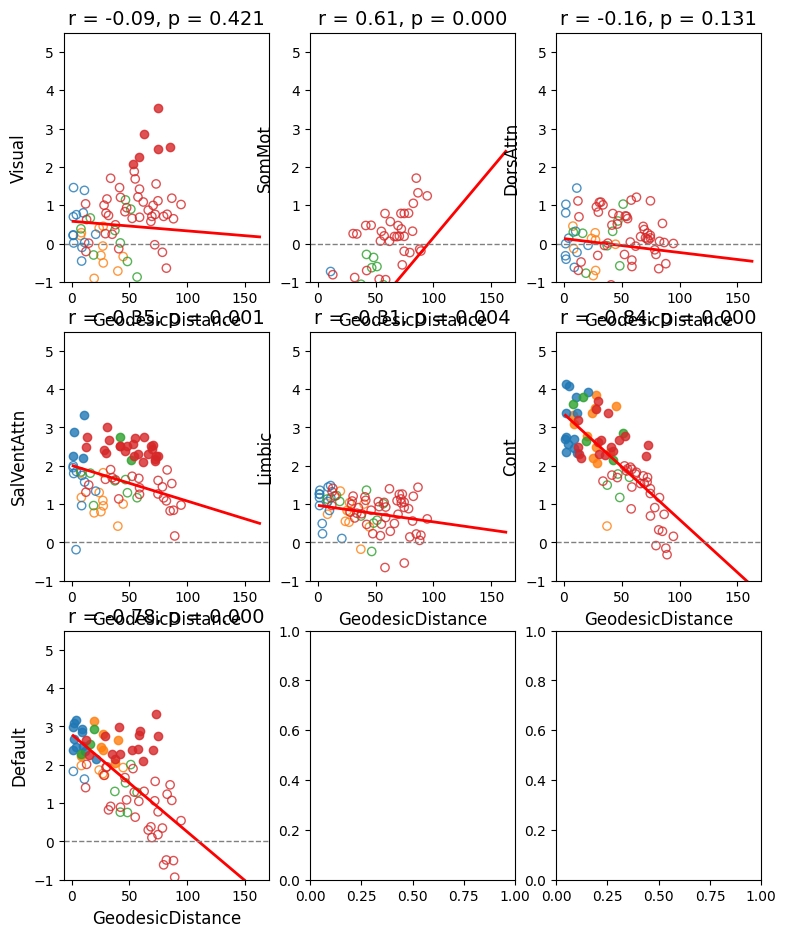

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Filter visual parcels
ttest_df = ttest_df[ttest_df.visual == 1]

# Define markers and colors per stream
STREAM_MARKERS = {
    'Primary': 'o',
    'Ventral': 'o',
    'Lateral': 'o',
    'Dorsal': 'o',
    None: 'o'#xD^s
}

STREAM_COLORS = {
    'Primary': 'tab:blue',
    'Ventral': 'tab:orange',
    'Lateral': 'tab:green',
    'Dorsal': 'tab:red',
    None: 'gray'
}

fig, axs = plt.subplots(3, 3, figsize=(9, 11))

for i, ax in enumerate(axs.flatten()[:7]):
    x = ttest_df['V1']
    y = ttest_df.iloc[:, i]
    r, p = pearsonr(x, y)
    centroids_subset = centroids[mask.values]
    sp = SpinPermutations(n_rep=10000, random_state=0)
    sp.fit(centroids_subset)
    # Randomize data (already subset)
    spun_data_all = sp.randomize(x.values)
    # Calculate observed correlation
    obs_corr = np.corrcoef(x, y)[0, 1]
    # Calculate null distribution correlations
    perm_corr = np.array([
        np.corrcoef(spun, y)[0, 1]
        for spun in spun_data_all
    ])
    # Compute two-tailed p-value
    pval = np.mean(np.abs(perm_corr) >= np.abs(obs_corr))
    print(f"Observed correlation: {obs_corr:.3f}")
    print(f"Spin test p-value: {pval:.4f}")

    # Fit regression line
    slope, intercept = np.polyfit(x, y, 1)
    x_vals = np.array([x.min(), x.max()])
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color='red', lw=2)

    # Get p-values for current column
    pvals = pvalue_df.iloc[:, i]

    # Masks for significance
    sig_mask = pvals < 0.05
    nonsig_mask = ~sig_mask

    # Scatter points by stream
    streams = ttest_df['stream']
    for stream in streams.unique():
        stream_mask = streams == stream

        # Significant: filled
        mask_sig = stream_mask & sig_mask
        ax.scatter(
            x[mask_sig],
            y[mask_sig],
            marker=STREAM_MARKERS.get(stream, 'o'),
            color=STREAM_COLORS.get(stream, 'gray'),
            alpha=0.8,
            label=f'{stream} (p<0.05)'
        )

        # Non-significant: hollow
        mask_ns = stream_mask & nonsig_mask
        ax.scatter(
            x[mask_ns],
            y[mask_ns],
            marker=STREAM_MARKERS.get(stream, 'o'),
            facecolors='none',
            edgecolors=STREAM_COLORS.get(stream, 'gray'),
            alpha=0.8,
            label=f'{stream} (n.s.)'
        )

    # Axes settings
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('GeodesicDistance', size=12)
    ax.set_ylabel(network_names[i], size=12)
    ax.set_ylim([-1, 5.5])
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', size=14)

    # Clean legend: avoid duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #ax.legend(by_label.values(), by_label.keys(), fontsize=10)

#plt.tight_layout()
plt.savefig('visual.eps')
plt.show()


In [123]:
blind_struc = pd.read_csv('../Derivatives/blind_structural_change.csv')
deaf_struc = pd.read_csv('../Derivatives/deaf_structural_change.csv')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Observed correlation: 0.515
Spin test p-value: 0.1378


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Observed correlation: -0.499
Spin test p-value: 0.1111


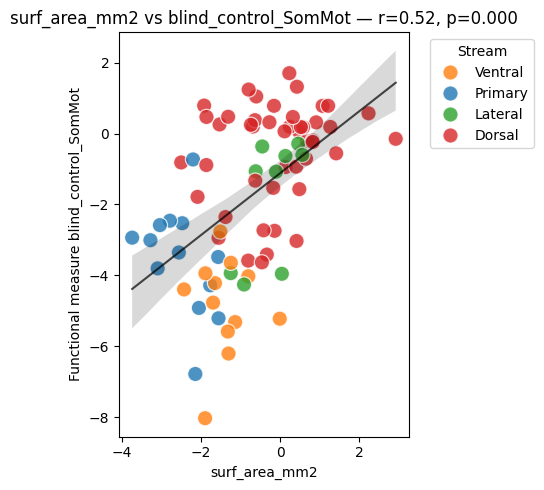

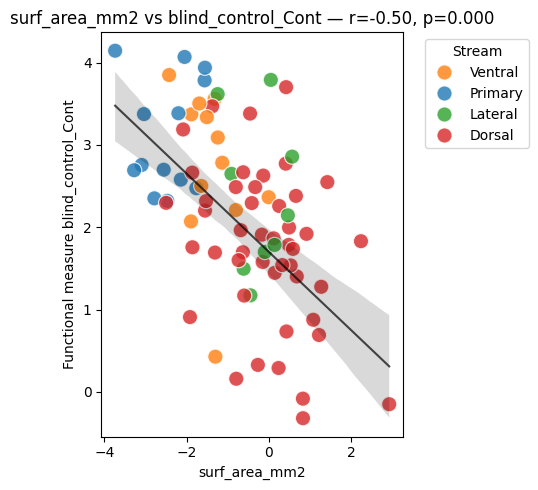

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import pandas as pd

x_vars = ['surf_area_mm2']
y_vars = ['blind_control_SomMot', 'blind_control_Cont']  # functional column

STREAM_COLORS = {
    'Primary': 'tab:blue',
    'Ventral': 'tab:orange',
    'Lateral': 'tab:green',
    'Dorsal': 'tab:red',
    None: 'gray'
}

# Filter for visual==1
mask = blind_struc.visual == 1
blind_struc_sub = blind_struc[mask]
blind_func_sub = ttest_df[ttest_df.visual==1]

for x in x_vars:
    for y in y_vars:
        plt.figure(figsize=(5,5))
        
        # Scatter colored by Stream
        sns.scatterplot(
            x=blind_struc_sub[x].values,
            y=blind_func_sub[y].values,
            hue=blind_func_sub['stream'],
            palette=STREAM_COLORS,
            s=120,
            alpha=0.8
        )
        
        # Overall correlation
        r, p = pearsonr(blind_struc_sub[x].dropna(), blind_func_sub[y].dropna())
        centroids_subset = centroids[mask.values]
        sp = SpinPermutations(n_rep=10000, random_state=0)
        sp.fit(centroids_subset)
        # Randomize data (already subset)
        spun_data_all = sp.randomize(blind_func_sub[y].dropna().values)
        # Calculate observed correlation
        obs_corr = np.corrcoef(blind_struc_sub[x].dropna(), blind_func_sub[y].dropna())[0, 1]
        # Calculate null distribution correlations
        perm_corr = np.array([
            np.corrcoef(spun, blind_struc_sub[x].dropna())[0, 1]
            for spun in spun_data_all
        ])
        # Compute two-tailed p-value
        pval = np.mean(np.abs(perm_corr) >= np.abs(obs_corr))
        print(f"Observed correlation: {obs_corr:.3f}")
        print(f"Spin test p-value: {pval:.4f}")
        
        # Regression line
        sns.regplot(
            x=blind_struc_sub[x],
            y=blind_func_sub[y],
            scatter=False,
            color='black',
            line_kws={'linewidth':1.5, 'alpha':0.7}
        )
        
        plt.xlabel(x)
        plt.ylabel(f'Functional measure {y}')
        plt.title(f'{x} vs {y} — r={r:.2f}, p={p:.3f}')
        plt.legend(title='Stream', bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.savefig('blind_'+x+'.eps')